# Milestone 2 - Baseline & Advanced Models
Split the data, build a base model, then a wide range of advanced models, evaluating each on **both train and test** with MAE / RMSE / R2 / MAPE / SMAPE and cross-validation.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from insurance import config, data, models, evaluate
from insurance.pipeline import build_pipeline

sns.set_theme(style="whitegrid")
df = data.load_clean()
X, y = data.split_X_y(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE)
print("train:", X_train.shape, "test:", X_test.shape)

train: (20000, 23) test: (5000, 23)


## 1. Base model
A `DummyRegressor` (predicts the mean) sets the floor; `LinearRegression` is the first real baseline.

In [2]:
for name, est in [("Dummy", DummyRegressor()), ("LinearRegression", LinearRegression())]:
    pipe = build_pipeline(est).fit(X_train, y_train)
    m = evaluate.evaluate_train_test(pipe, X_train, y_train, X_test, y_test)
    print(f"{name:18s} test R2={m['test_R2']:.4f}  test RMSE={m['test_RMSE']:.1f}  test MAE={m['test_MAE']:.1f}")

Dummy              test R2=-0.0000  test RMSE=14273.6  test MAE=11762.0


LinearRegression   test R2=0.9447  test RMSE=3355.9  test MAE=2710.2


## 2. Advanced models
Linear/regularized, tree, and ensemble/boosting families (including XGBoost, LightGBM, CatBoost when available).

In [3]:
rows = []
for name, est in models.get_models().items():
    pipe = build_pipeline(est).fit(X_train, y_train)
    row = {"model": name}
    row.update(evaluate.evaluate_train_test(pipe, X_train, y_train, X_test, y_test))
    cv_mean, cv_std = evaluate.cross_val_rmse(pipe, X_train, y_train, cv=3)
    row["cv_rmse_mean"] = cv_mean
    rows.append(row)
comparison = pd.DataFrame(rows).sort_values("test_RMSE").reset_index(drop=True)
comparison[["model", "test_MAE", "test_RMSE", "test_R2", "train_R2", "cv_rmse_mean", "train_test_RMSE_gap"]].round(3)

,model,test_MAE,test_RMSE,test_R2,train_R2,cv_rmse_mean,train_test_RMSE_gap
0,LightGBM,2328.382,2909.172,0.958,0.964,2975.279,195.218
1,HistGradientBoosting,2334.436,2911.705,0.958,0.962,2969.155,112.246
2,GradientBoosting,2367.703,2944.151,0.957,0.958,2979.133,4.291
3,CatBoost,2360.008,2946.324,0.957,0.970,3007.266,464.579
4,RandomForest,2380.823,3006.095,0.956,0.994,3060.937,1865.289
5,XGBoost,2427.639,3034.263,0.955,0.978,3122.070,906.180
6,ExtraTrees,2488.563,3152.681,0.951,1.000,3164.414,3152.681
7,Lasso,2709.290,3354.717,0.945,0.945,3356.087,7.225
8,LinearRegression,2710.244,3355.857,0.945,0.945,3357.042,8.459
9,Ridge,2710.197,3355.885,0.945,0.945,3357.028,8.485


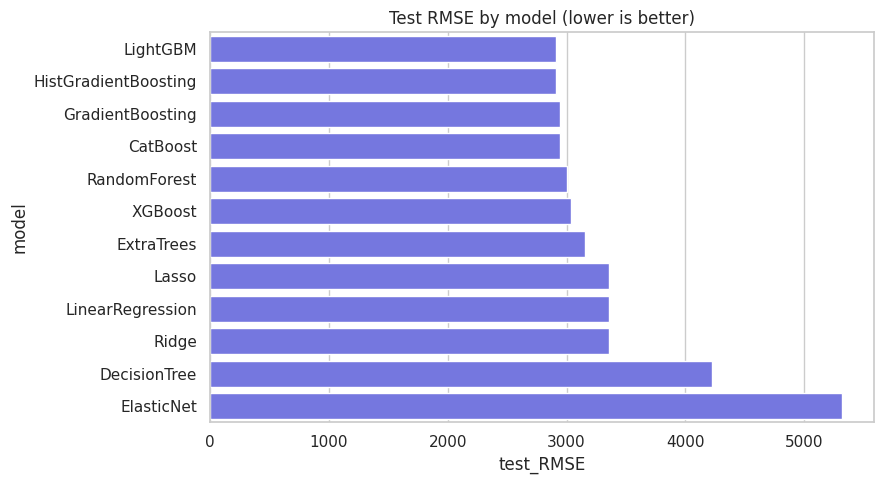

In [4]:
plot_df = comparison[comparison.model != "DummyRegressor"]
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, y="model", x="test_RMSE", color="#6366f1")
plt.title("Test RMSE by model (lower is better)")
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "model_comparison.png", dpi=120); plt.show()

**Observation:** Gradient-boosting models (LightGBM, HistGradientBoosting, GradientBoosting, CatBoost) lead with test R2 ~ 0.958 and the lowest RMSE/MAE. Tree ensembles like RandomForest/ExtraTrees overfit (large train/test gap). Linear models plateau at R2 ~ 0.945. The boosting models are taken forward to tuning.